# Drug Review Sentiment Analysis
### NLP Project | UCI Drug Review Dataset

---

## Objective
Analyze **215,063 real patient drug reviews** to automatically classify sentiment as **Positive, Neutral, or Negative** using Natural Language Processing (NLP) and Machine Learning.

Patients rate drugs on a scale of 1–10 and write free-text reviews. The goal is to train a model that can predict sentiment from the review text alone — without relying on the numeric rating.

---

## Dataset
| Property | Detail |
|----------|--------|
| Source | UCI ML Repository / Kaggle |
| Total Reviews | 215,063 |
| Train Split | 161,297 |
| Test Split | 53,766 |
| Features | Drug name, condition, review text, rating (1–10), useful votes |

---

## Workflow
1. Data Loading & Exploratory Data Analysis (EDA)
2. Text Cleaning & Preprocessing
3. Sentiment Labeling
4. TF-IDF Vectorization
5. Model Building — Logistic Regression & Naive Bayes
6. Evaluation, Insights & Conclusions

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading data
train = pd.read_csv('drugsComTrain_raw.csv')
test = pd.read_csv('drugsComTest_raw.csv')

# Combining both
df = pd.concat([train, test], ignore_index=True)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Combined shape:", df.shape)

Train shape: (161297, 7)
Test shape: (53766, 7)
Combined shape: (215063, 7)


---

## 1. Exploratory Data Analysis

Before building any model, we explore the dataset to understand its structure, distributions, and patterns.

In [28]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


### Dataset Info & Null Values
Checking data types and missing values across all columns.

In [5]:
print(df.info())
print()
print("Null values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 215063 entries, 0 to 215062
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   uniqueID     215063 non-null  int64
 1   drugName     215063 non-null  str  
 2   condition    213869 non-null  str  
 3   review       215063 non-null  str  
 4   rating       215063 non-null  int64
 5   date         215063 non-null  str  
 6   usefulCount  215063 non-null  int64
dtypes: int64(3), str(4)
memory usage: 11.5 MB
None

Null values:
 uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64


### Rating Distribution
Ratings range from 1 to 10. The distribution is heavily skewed towards higher ratings — patients who are satisfied with a drug tend to write reviews more than those who are indifferent.

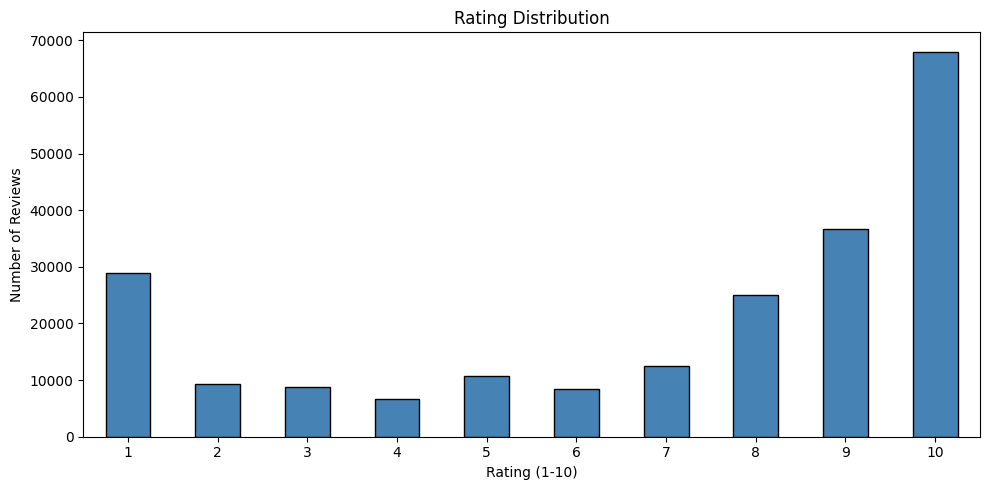

rating
1     28918
2      9265
3      8718
4      6671
5     10723
6      8462
7     12547
8     25046
9     36708
10    68005
Name: count, dtype: int64


In [30]:
plt.figure(figsize=(10, 5))
df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating (1-10)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['rating'].value_counts().sort_index())

### Top 15 Medical Conditions
Birth control, depression, and pain dominate the dataset — reflecting conditions where patients actively seek peer experiences before or during treatment.

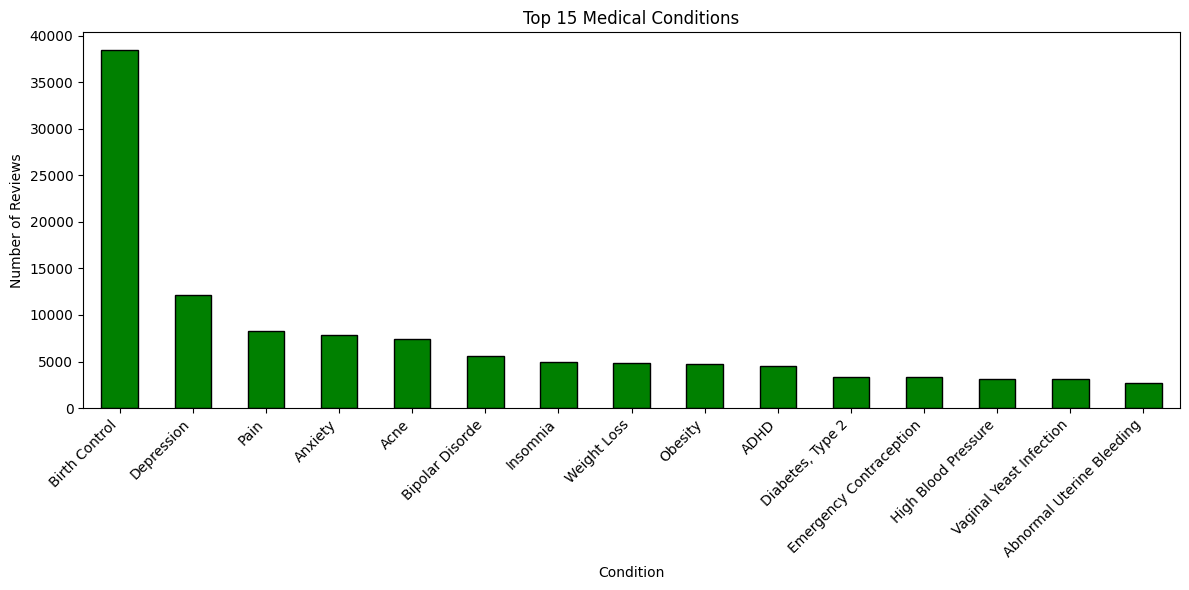

In [32]:
plt.figure(figsize=(12, 6))
df['condition'].value_counts().head(15).plot(kind='bar', color='green', edgecolor='black')
plt.title('Top 15 Medical Conditions')
plt.xlabel('Condition')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top 15 Most Reviewed Drugs
Drugs associated with chronic conditions (contraceptives, antidepressants, pain medication) receive the most reviews — consistent with long-term patient engagement.

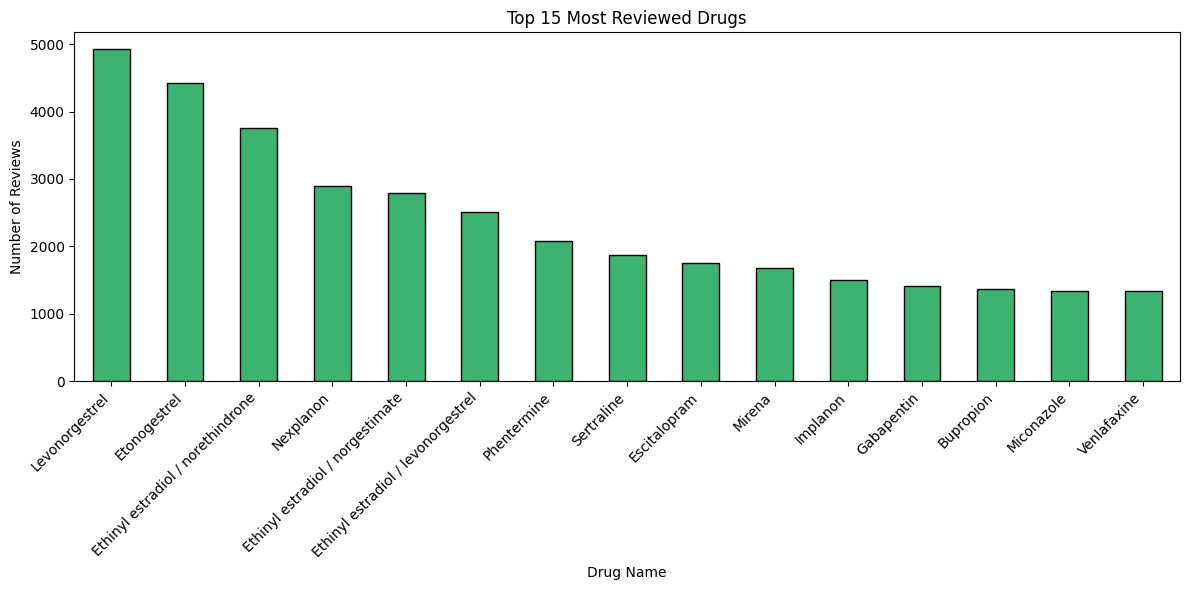

In [33]:
plt.figure(figsize=(12, 6))
df['drugName'].value_counts().head(15).plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Top 15 Most Reviewed Drugs')
plt.xlabel('Drug Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Review Length Distribution
Analyzing how many words patients typically write in their reviews.

Average review length: 84.7 words
Shortest review: 1 words
Longest review: 1894 words


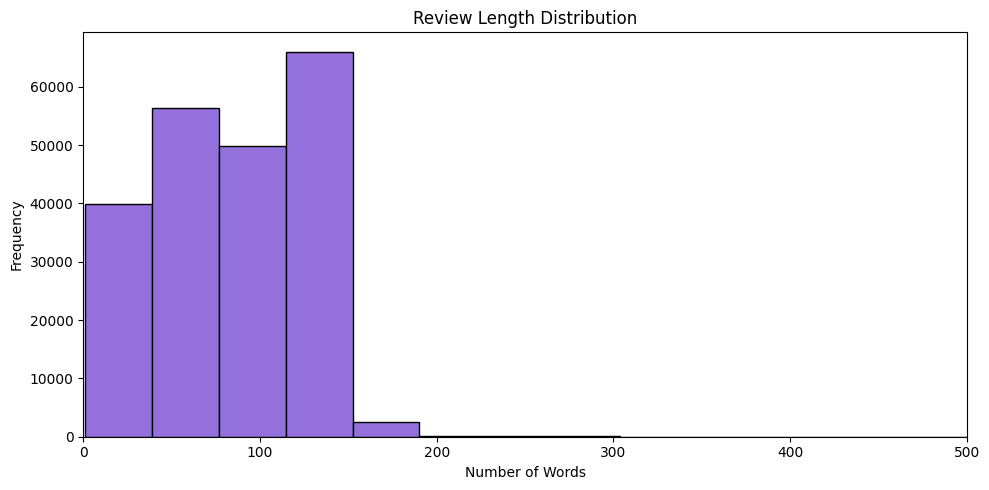

In [34]:
# New column added to find the length of each review 
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

print("Average review length:", round(df['review_length'].mean(), 1), "words")
print("Shortest review:", df['review_length'].min(), "words")
print("Longest review:", df['review_length'].max(), "words")

plt.figure(figsize=(10, 5))
df['review_length'].plot(kind='hist', bins=50, color='mediumpurple', edgecolor='black')
plt.title('Review Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 500)
plt.tight_layout()
plt.show()

**Key observations:**
- Average review length: **84.7 words** — enough context for sentiment analysis
- Shortest: 1 word | Longest: 1,894 words
- Distribution is right-skewed — most reviews are concise (50–150 words)

---

## 2. Text Cleaning & Preprocessing

Raw reviews contain HTML entities (`&#039;`), punctuation, numbers, stopwords, and inconsistent casing. All of this is noise for an NLP model — we need to strip it down to meaningful words only.

In [35]:
import re
import html
from sklearn.preprocessing import LabelEncoder

# nltk downloads
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Cleaning Pipeline
Each review goes through 6 steps:
1. **HTML decode** — `&#039;` → `'`, `&amp;` → `&`
2. **Remove HTML tags** — strip any `<br>`, `<p>` etc.
3. **Lowercase** — standardize all text
4. **Remove punctuation & numbers** — keep only alphabetic words
5. **Remove extra whitespace**
6. **Remove stopwords** — drop common words like "the", "is", "and" that carry no sentiment signal

In [36]:
def clean_text(text):
    # Decoding HTML entities  (&amp; -> &,  &#039; -> ')
    text = html.unescape(str(text))
    
    # Removing HTML tags if any (<br>, <p> etc)
    text = re.sub(r'<.*?>', ' ', text)
    
    # Lowercased everything
    text = text.lower()
    
    # Removed punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Removed extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Removed stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    
    return text

# Testing it on one review before applying to full data
sample = df['review'].iloc[2]
print("BEFORE:\n", sample)
print()
print("AFTER:\n", clean_text(sample))

BEFORE:
 "I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very light periods, max 5 days, no other side effects. But it contained hormone gestodene, which is not available in US, so I switched to Lybrel, because the ingredients are similar. When my other pills ended, I started Lybrel immediately, on my first day of period, as the instructions said. And the period lasted for two weeks. When taking the second pack- same two weeks. And now, with third pack things got even worse- my third period lasted for two weeks and now it&#039;s the end of the third week- I still have daily brown discharge.
The positive side is that I didn&#039;t have any other side effects. The idea of being period free was so tempting... Alas."

AFTER:
 used take another oral contraceptive pill cycle happy light periods max days side effects contained hormone gestodene available us switched lybrel ingredients similar pills ended started lybrel immediately first day period inst

**Example output:**
- Before: *"It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"*
- After: *"side effect take combination bystolic mg fish oil"*

Only 7 meaningful words remain from 18 — exactly what the model needs.

In [38]:
# Applying on full dataset
df['cleaned_review'] = df['review'].apply(clean_text)
print()
# original vs cleaned
print("Original:", df['review'].iloc[3])
print()
print("Cleaned:", df['cleaned_review'].iloc[0])


Original: "This is my first time using any form of birth control. I&#039;m glad I went with the patch, I have been on it for 8 months. At first It decreased my libido but that subsided. The only downside is that it made my periods longer (5-6 days to be exact) I used to only have periods for 3-4 days max also made my cramps intense for the first two days of my period, I never had cramps before using birth control. Other than that in happy with the patch"

Cleaned: side effect take combination bystolic mg fish oil


---

## 3. Sentiment Labeling

Ratings are converted into 3 sentiment categories:

| Rating | Sentiment |
|--------|-----------|
| 1 – 4 | Negative |
| 5 – 6 | Neutral |
| 7 – 10 | Positive |

sentiment
Positive    142306
Negative     53572
Neutral      19185
Name: count, dtype: int64



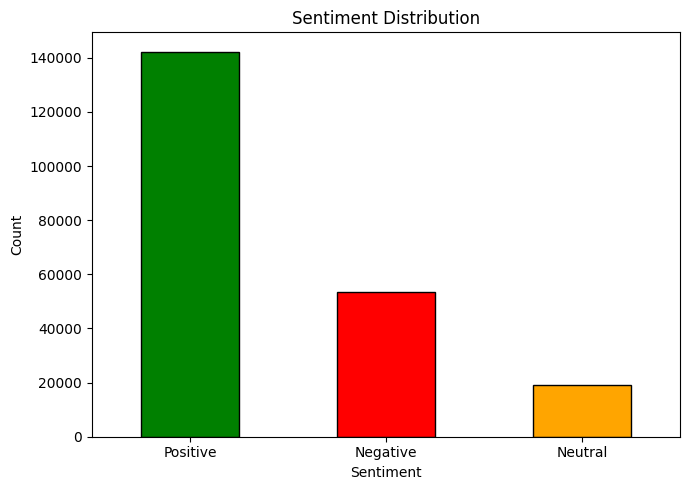

In [39]:
# Converting rating (1-10) into 3 sentiment categories
def get_sentiment(rating):
    if rating <= 4:
        return 'Negative'
    elif rating <= 6:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(get_sentiment)

# Checking the distribution
print(df['sentiment'].value_counts())
print()

# Sentiment plot
plt.figure(figsize=(7, 5))
df['sentiment'].value_counts().plot(kind='bar', 
                                     color=['green', 'red', 'orange'], 
                                     edgecolor='black')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Class distribution:**
- Positive: 142,306 (66%)
- Negative: 53,572 (25%)
- Neutral: 19,185 (9%)

> **Note — Class Imbalance:** The dataset is heavily skewed towards Positive reviews. A naive model that always predicts Positive would achieve 66% accuracy. This imbalance will impact Neutral class performance, which we address in the evaluation section.

---

## 4. TF-IDF Vectorization

Machine learning models only understand numbers — not text. TF-IDF (Term Frequency–Inverse Document Frequency) converts each review into a numerical vector.

- **TF** — how often a word appears in this review
- **IDF** — how rare the word is across all reviews (rare words carry more meaning)

This means common words like "the" get near-zero weight, while meaningful words like "lifesaver" get high weight.

**Parameters used:**
- `max_features=10000` — keep only the top 10,000 most frequent words
- `ngram_range=(1,2)` — capture both single words and two-word phrases ("side effect", "highly recommend")

In [40]:
from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train size:", len(X_train))
print("X_test size:", len(X_test))
print()
print("Train sentiment distribution:")
print(y_train.value_counts())

X_train size: 172050
X_test size: 43013

Train sentiment distribution:
sentiment
Positive    113845
Negative     42857
Neutral      15348
Name: count, dtype: int64


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

TF-IDF matrix shape (train): (172050, 10000)
TF-IDF matrix shape (test): (43013, 10000)


Each review is now represented as a row of **10,000 numbers** ready for model training.

---

## 5. Model Building

Two models are trained and compared:
- **Logistic Regression** — linear classifier that finds a decision boundary between classes
- **Multinomial Naive Bayes** — probabilistic classifier that calculates word probabilities per class

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred_lr) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred_lr))

Accuracy: 80.84 %

              precision    recall  f1-score   support

    Negative       0.74      0.72      0.73     10715
     Neutral       0.44      0.09      0.15      3837
    Positive       0.84      0.94      0.89     28461

    accuracy                           0.81     43013
   macro avg       0.67      0.58      0.59     43013
weighted avg       0.78      0.81      0.78     43013



In [43]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Results:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_nb) * 100, 2), "%")
print()
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:
Accuracy: 76.35 %

              precision    recall  f1-score   support

    Negative       0.74      0.50      0.60     10715
     Neutral       0.59      0.00      0.01      3837
    Positive       0.77      0.96      0.86     28461

    accuracy                           0.76     43013
   macro avg       0.70      0.49      0.49     43013
weighted avg       0.74      0.76      0.72     43013



---

## 6. Model Comparison & Evaluation

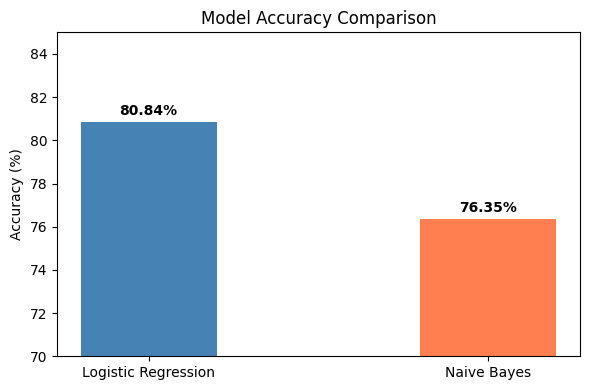

In [46]:
models = ['Logistic Regression', 'Naive Bayes']
accuracies = [80.84, 76.35]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=['steelblue', 'coral'], width=0.4)
plt.bar_label(bars, fmt='%.2f%%', padding=3, fontweight='bold')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 85)
plt.tight_layout()
plt.show()

**Logistic Regression (80.84%) outperforms Naive Bayes (76.35%).**

Logistic Regression handles the high-dimensional sparse TF-IDF matrix better — it can learn complex weight combinations across 10,000 features, whereas Naive Bayes assumes word independence which is too simplistic for nuanced medical language.

### Confusion Matrix — Logistic Regression

<Figure size 800x600 with 0 Axes>

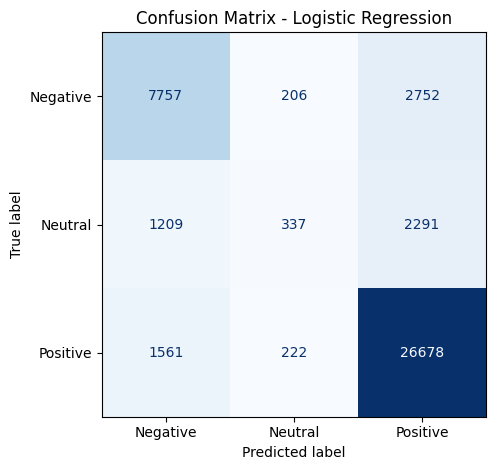

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr, labels=['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

**Reading the matrix:**
- **Positive class** — 26,678 correctly identified out of 28,461 (excellent)
- **Negative class** — 7,757 correctly identified out of 10,715 (good)
- **Neutral class** — only 337 correctly identified out of 3,837 (poor — class imbalance effect)

The model's biggest error: 2,752 negative reviews predicted as positive — because negative reviews often contain positive words in context ("the drug *worked* but side effects were *terrible*").

---

## 7. Insights

In [48]:
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vectorized = tfidf.transform([cleaned])
    prediction = lr.predict(vectorized)[0]
    probability = lr.predict_proba(vectorized)[0]
    classes = lr.classes_
    
    print(f"Review: {review_text}")
    print(f"Predicted Sentiment: {prediction}")
    print(f"Confidence:")
    for cls, prob in zip(classes, probability):
        print(f"  {cls}: {round(prob*100, 1)}%")
    print()

# Test with different reviews
predict_sentiment("This medicine completely cured my anxiety, I feel amazing!")
predict_sentiment("Terrible drug, made me feel worse and had horrible side effects")
predict_sentiment("It was okay, nothing special, worked sometimes")
predict_sentiment("The medicine helped me initially but later was not effective")

Review: This medicine completely cured my anxiety, I feel amazing!
Predicted Sentiment: Positive
Confidence:
  Negative: 0.1%
  Neutral: 0.5%
  Positive: 99.4%

Review: Terrible drug, made me feel worse and had horrible side effects
Predicted Sentiment: Negative
Confidence:
  Negative: 99.1%
  Neutral: 0.7%
  Positive: 0.2%

Review: It was okay, nothing special, worked sometimes
Predicted Sentiment: Positive
Confidence:
  Negative: 11.1%
  Neutral: 11.4%
  Positive: 77.5%

Review: The medicine helped me initially but later was not effective
Predicted Sentiment: Positive
Confidence:
  Negative: 2.9%
  Neutral: 12.6%
  Positive: 84.6%



### Word Cloud — Positive vs Negative Reviews
Visualizing the most common words in each sentiment class.

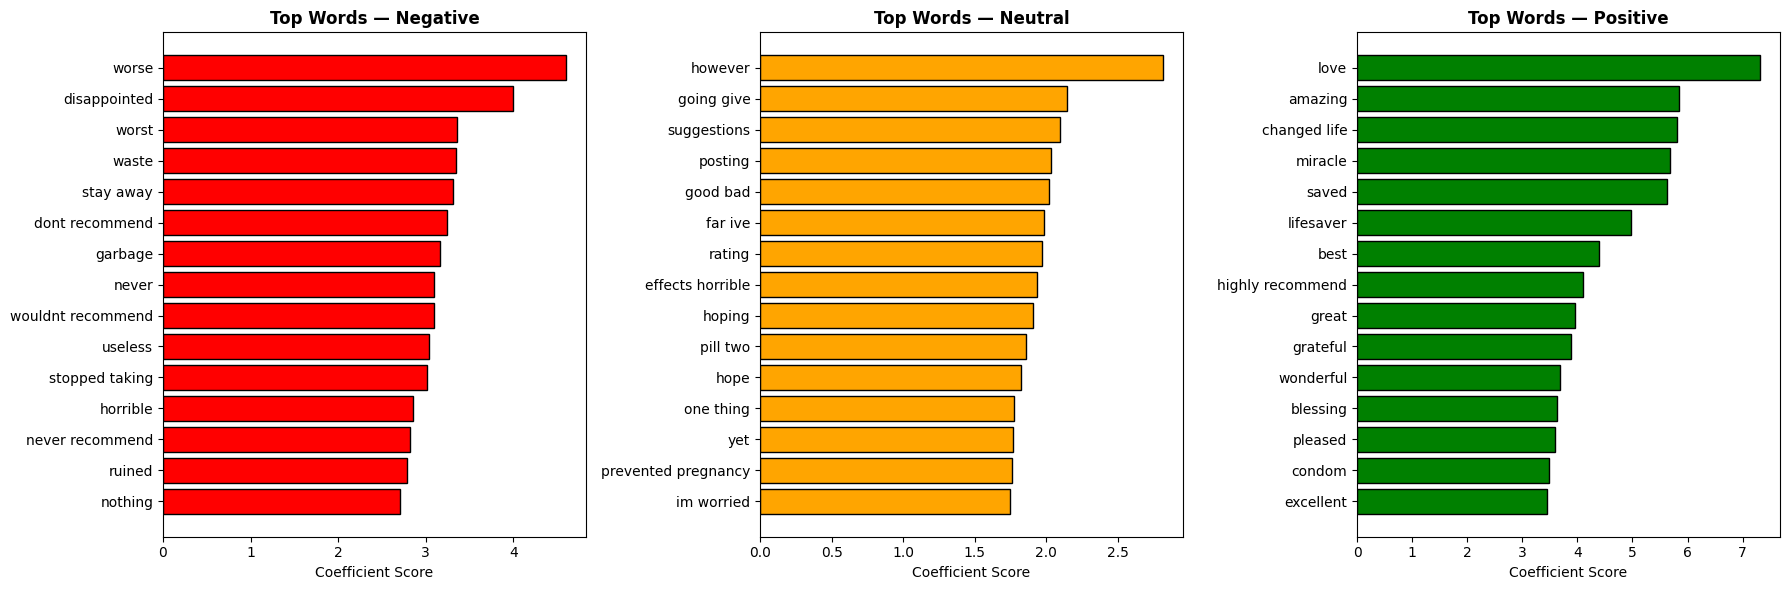

In [24]:
# Get feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Get LR coefficients for each class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
classes = lr.classes_
colors = ['red', 'orange', 'green']

for i, (cls, color) in enumerate(zip(classes, colors)):
    # Get top 15 words for this class
    coef = lr.coef_[i]
    top_indices = coef.argsort()[-15:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    top_scores = [coef[j] for j in top_indices]
    
    axes[i].barh(top_words[::-1], top_scores[::-1], color=color, edgecolor='black')
    axes[i].set_title(f'Top Words — {cls}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Coefficient Score')

plt.tight_layout()
plt.show()

### Top Words Driving Each Sentiment
These are the actual words the Logistic Regression model learned to associate with each class — the interpretable "brain" of the classifier.

**Key observations:**
- **Negative drivers:** worse, disappointed, horrible, ruined, useless, dont recommend — strong complaint vocabulary
- **Neutral drivers:** however, hoping, yet, good bad — uncertainty and on-the-fence language
- **Positive drivers:** love, amazing, changed life, miracle, lifesaver, grateful — highly emotional positive language

Patients who are happy with a drug write with strong emotion. Patients who are unhappy write with strong frustration. Neutral patients are still waiting to see results.

### Helpful Votes by Sentiment

Average helpful votes by sentiment:
sentiment
Negative    15.97
Neutral     18.40
Positive    33.83
Name: usefulCount, dtype: float64



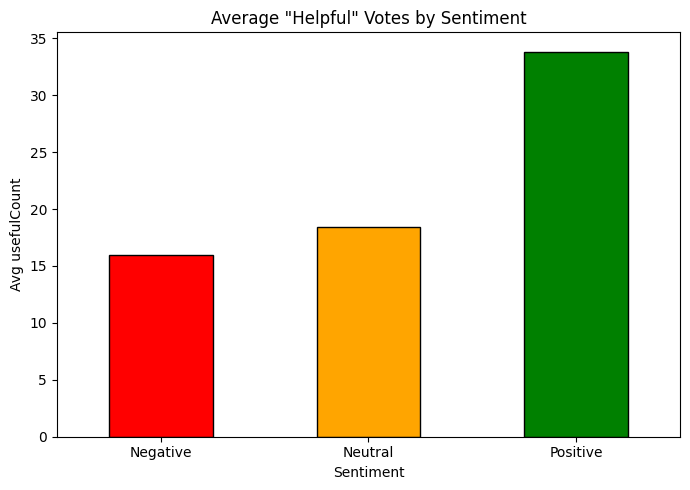

In [25]:
# Average usefulCount by sentiment
useful_by_sentiment = df.groupby('sentiment')['usefulCount'].mean().round(2)
print("Average helpful votes by sentiment:")
print(useful_by_sentiment)
print()

plt.figure(figsize=(7, 5))
useful_by_sentiment.plot(kind='bar', 
                          color=['red', 'orange', 'green'], 
                          edgecolor='black')
plt.title('Average "Helpful" Votes by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Avg usefulCount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Surprising finding:** Positive reviews receive **2x more helpful votes** (33.83) than negative reviews (15.97).

This is counter-intuitive — we expected negative reviews (warnings about side effects) to be more helpful. The likely explanation: patients searching for drug information are primarily asking "will this work for me?" — a detailed positive experience is more actionable than emotional venting.

---

## 8. Conclusions

| Model | Accuracy |
|-------|----------|
| Logistic Regression | **80.84%** |
| Naive Bayes | 76.35% |

**Key findings:**
- Logistic Regression with TF-IDF bigrams achieves **80.84% accuracy** on 43,013 test reviews
- Neutral class is significantly underperforming (F1: 0.15) due to class imbalance
- Positive reviews attract 2x more helpful votes than negative ones
- Top sentiment signals are highly interpretable and medically meaningful

---

## Limitations & Future Work

**Current limitation:**
TF-IDF + Logistic Regression works well for clearly positive or negative reviews but struggles with nuanced, mixed-sentiment text. The model sees "helped" and predicts Positive without understanding the "but later" reversal — a fundamental limitation of bag-of-words approaches that ignore word order.